Compile Engrave AT2017gfo Spectra

# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

In [5]:
path_data = os.path.join(RAW_DATA, "Engrave/flux_corrected_unsmoothed_spectra")
print(path_data)

/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra


# Data

In [7]:
VIS_files = sorted(glob.glob(f"{path_data}/VIS*.dat"))
UVB_files = sorted(glob.glob(f"{path_data}/UVB*.dat"))
NIR_files = sorted(glob.glob(f"{path_data}/NIR*.dat"))

all_files = VIS_files + UVB_files + NIR_files

print(f"VIS files: {len(VIS_files)}")
print(f"UVB files: {len(UVB_files)}")
print(f"NIR files: {len(NIR_files)}")

VIS files: 10
UVB files: 9
NIR files: 10


- Initialization

In [65]:
summary_table = Table()
phases = [float(os.path.basename(filename).split('_')[-1].replace('Phase', '').replace('.dat', '').replace('d', '')) for filename in VIS_files]
summary_table['phase'] = phases
summary_table['wavelength'] = "TBD"
summary_table['mjd'] = 0.0
summary_table['path_data'] = " "*500
summary_table['filename'] = " "*100

In [15]:
for filename in all_files:
    part = os.path.basename(filename).split('_')
    wavelength = part[0]
    mjd = float(part[5].split("-")[1])
    phase = float(part[-1].replace('Phase', '').replace('.dat', '').replace('d', ''))

    indx_phase = summary_table['phase'] == phase
    summary_table['wavelength'][indx_phase] = wavelength
    summary_table['mjd'][indx_phase] = mjd
    summary_table['path_data'][indx_phase] = filename
    summary_table['filename'][indx_phase] = os.path.basename(filename)

summary_table

phase,wavelength,mjd,path_data,filename
float64,str3,float64,str500,str100
1.43,NIR,57983.969,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57983.969_Phase+1.43d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57983.969_Phase+1.43d.dat
2.42,NIR,57984.969,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57984.969_Phase+2.42d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57984.969_Phase+2.42d.dat
3.41,NIR,57985.974,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57985.974_Phase+3.41d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57985.974_Phase+3.41d.dat
4.4,NIR,57986.974,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57986.974_Phase+4.40d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57986.974_Phase+4.40d.dat
5.4,NIR,57987.98,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57987.980_Phase+5.40d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57987.980_Phase+5.40d.dat
6.4,NIR,57988.99,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57988.990_Phase+6.40d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57988.990_Phase+6.40d.dat
7.4,NIR,57990.0,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57990.000_Phase+7.40d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57990.000_Phase+7.40d.dat
8.4,NIR,57991.0,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57991.000_Phase+8.40d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57991.000_Phase+8.40d.dat
9.4,NIR,57992.0,/home/gpaek/SED-Classifier/notebook/../data/raw_data/Engrave/flux_corrected_unsmoothed_spectra/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57992.000_Phase+9.40d.dat,NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57992.000_Phase+9.40d.dat


In [24]:
vistbl = Table.read(VIS_files[0], format='ascii.commented_header')
nirtbl = Table.read(NIR_files[0], format='ascii.commented_header')
uvbtbl = Table.read(UVB_files[0], format='ascii.commented_header')

In [57]:
print(np.min(uvbtbl['wavelength']), np.max(uvbtbl['wavelength']))
print(np.min(vistbl['wavelength']), np.max(vistbl['wavelength']))
print(np.min(nirtbl['wavelength']), np.max(nirtbl['wavelength']))


2991.39409098 5900.69473187
5359.60361651 10201.1250348
9941.50673699 24793.1627319


In [50]:
vis_del_lam = np.median(vistbl['wavelength'][1:].value - vistbl['wavelength'][:-1].value)
nir_del_lam = np.median(nirtbl['wavelength'][1:].value - nirtbl['wavelength'][:-1].value)
uvb_del_lam = np.median(uvbtbl['wavelength'][1:].value - uvbtbl['wavelength'][:-1].value)

print(f"VIS: {vis_del_lam:.3f} AA")
print(f"NIR: {nir_del_lam:.3f} AA")
print(f"UVB: {uvb_del_lam:.3f} AA")

VIS: 0.200 AA
NIR: 0.600 AA
UVB: 0.200 AA


In [27]:
fulltbl = vstack([uvbtbl, vistbl, nirtbl])
# fulltbl

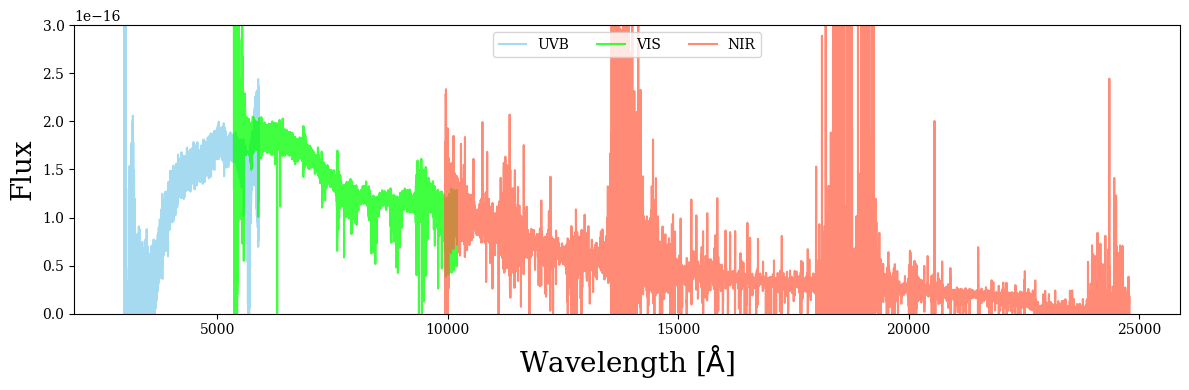

In [58]:
fig = plt.figure(figsize=(12, 4))

plt.plot(uvbtbl['wavelength'], uvbtbl['flux_tell_corrected'], c='skyblue', alpha=0.75, label='UVB')
plt.plot(vistbl['wavelength'], vistbl['flux_tell_corrected'], c='lime', alpha=0.75, label='VIS')
plt.plot(nirtbl['wavelength'], nirtbl['flux_tell_corrected'], c='tomato', alpha=0.75, label='NIR')

plt.ylim(0, 3e-16)
plt.xlabel(r"Wavelength [$\rm \AA$]")
plt.ylabel("Flux")
plt.legend(loc='upper center', ncol=3)
plt.tight_layout()

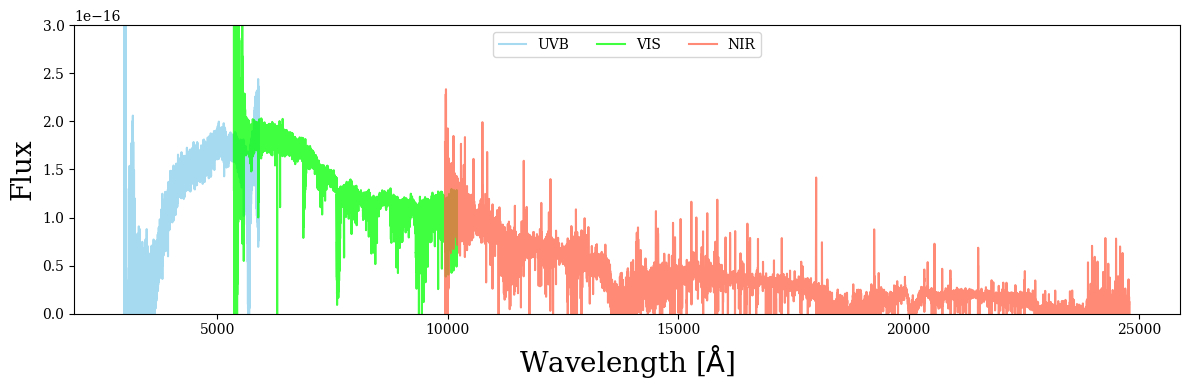

In [62]:
fig = plt.figure(figsize=(12, 4))

plt.plot(uvbtbl['wavelength'], uvbtbl['flux_not_tell_corrected'], c='skyblue', alpha=0.75, label='UVB')
plt.plot(vistbl['wavelength'], vistbl['flux_not_tell_corrected'], c='lime', alpha=0.75, label='VIS')
plt.plot(nirtbl['wavelength'], nirtbl['flux_not_tell_corrected'], c='tomato', alpha=0.75, label='NIR')

plt.ylim(0, 3e-16)
plt.xlabel(r"Wavelength [$\rm \AA$]")
plt.ylabel("Flux")
plt.legend(loc='upper center', ncol=3)
plt.tight_layout()

In [63]:
import numpy as np
from astropy.table import Table, vstack
from collections import defaultdict

def merge_spectra_average_overlap(uvbtbl, vistbl, nirtbl,
                                   flux_key='flux_not_tell_corrected',
                                   precision=0.2,
                                   interp_range=100):
    # 병합 및 정렬
    full_tbl = vstack([uvbtbl, vistbl, nirtbl])
    full_tbl.sort('wavelength')

    # 파장을 소수점 precision 단위로 binning
    wl_round = np.round(full_tbl['wavelength'] / precision) * precision

    # bin 단위로 flux 모으기
    flux_acc = defaultdict(list)
    for wl, flux in zip(wl_round, full_tbl[flux_key]):
        flux_acc[wl].append(flux)

    # 평균값 테이블 생성
    merged_wavelengths = []
    merged_fluxes = []

    for wl_bin in sorted(flux_acc.keys()):
        merged_wavelengths.append(wl_bin)
        merged_fluxes.append(np.mean(flux_acc[wl_bin]))

    merged_tbl = Table()
    merged_tbl['wavelength'] = np.array(merged_wavelengths)
    merged_tbl['flux'] = np.array(merged_fluxes)

    # 음수 flux를 보간으로 대체
    for i, (wl, flux) in enumerate(zip(merged_tbl['wavelength'], merged_tbl['flux'])):
        if flux < 0:
            # 보간용 후보군: ±interp_range 이내에서 flux > 0인 항목
            mask = (
                (merged_tbl['wavelength'] >= wl - interp_range) &
                (merged_tbl['wavelength'] <= wl + interp_range) &
                (merged_tbl['flux'] > 0)
            )
            nearby = merged_tbl[mask]
            if len(nearby) >= 2:
                # 보간 수행
                merged_tbl['flux'][i] = np.interp(wl, nearby['wavelength'], nearby['flux'])
            else:
                merged_tbl['flux'][i] = np.nan  # 적절한 보간 후보가 없으면 NaN으로 남김

    return merged_tbl


In [72]:
def bin_spectrum(tbl, bin_width=10, flux_key='flux_not_tell_corrected'):
    # 최소~최대 파장 범위
    wl_min = np.min(tbl['wavelength'])
    wl_max = np.max(tbl['wavelength'])
    
    # bin edge 및 center 정의
    bins = np.arange(wl_min, wl_max + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # bin 내 평균 계산
    digitized = np.digitize(tbl['wavelength'], bins) - 1  # bin index (0-based)
    
    binned_flux = []
    for i in range(len(bin_centers)):
        bin_flux = tbl[flux_key][digitized == i]
        if len(bin_flux) > 0:
            binned_flux.append(np.mean(bin_flux))
        else:
            binned_flux.append(np.nan)

    binned_tbl = Table()
    binned_tbl['wavelength'] = bin_centers
    binned_tbl['flux'] = binned_flux
    return binned_tbl

In [68]:
phases[:7]

[1.43, 2.42, 3.41, 4.4, 5.4, 6.4, 7.4]

> Start processing for a phase=1.43d
Read tables
Merge tables and Save
Plot


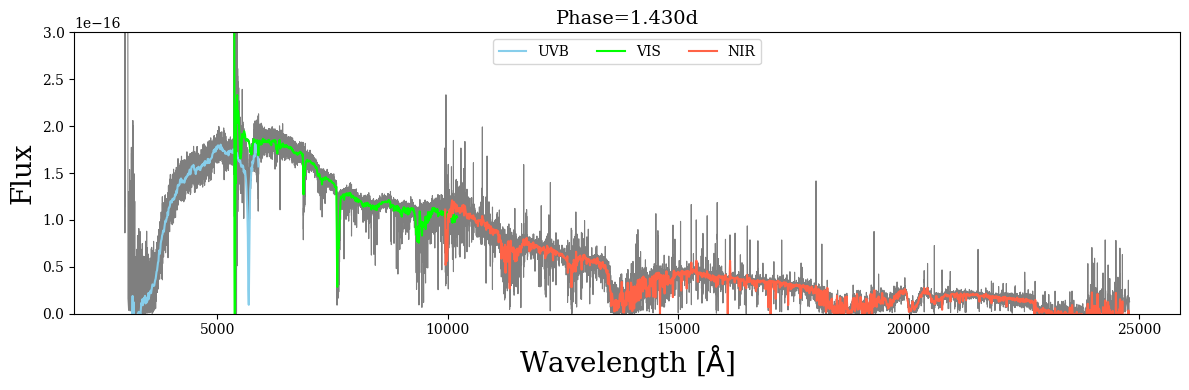

> Start processing for a phase=2.42d
Read tables
Merge tables and Save
Plot


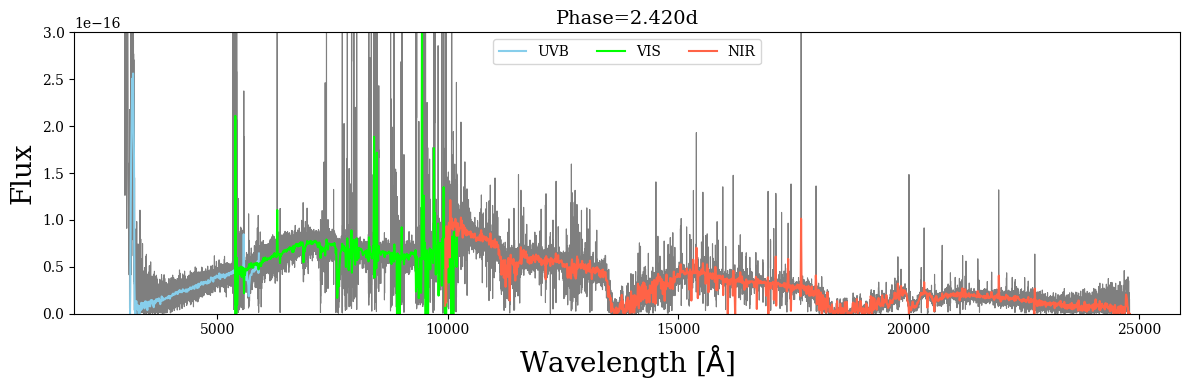

> Start processing for a phase=3.41d
Read tables
Merge tables and Save
Plot


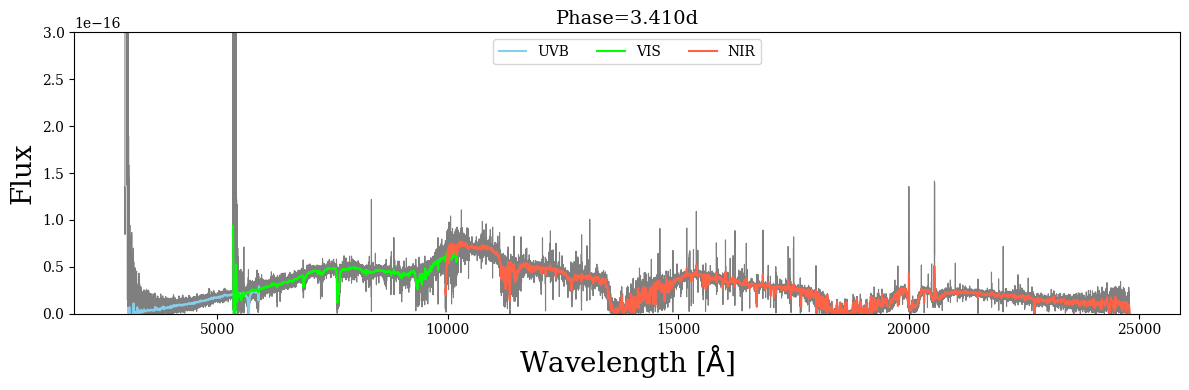

> Start processing for a phase=4.4d
Read tables
Merge tables and Save
Plot


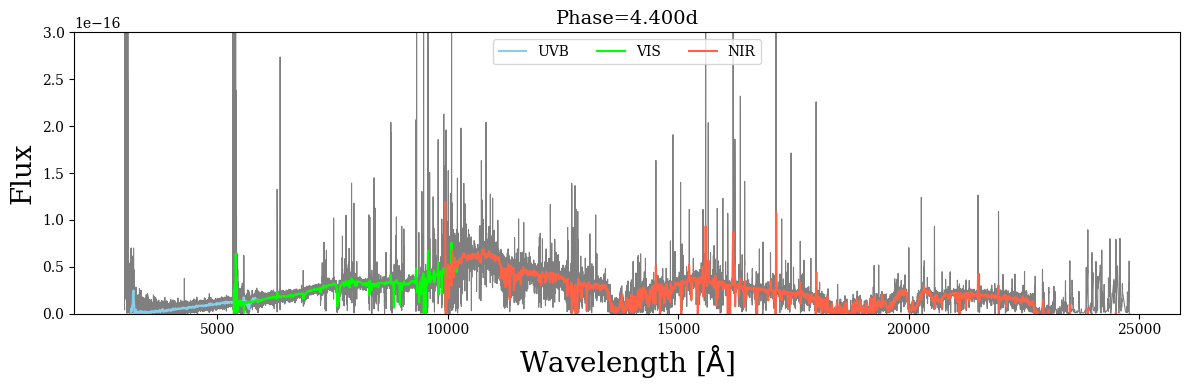

> Start processing for a phase=5.4d
Read tables
Merge tables and Save
Plot


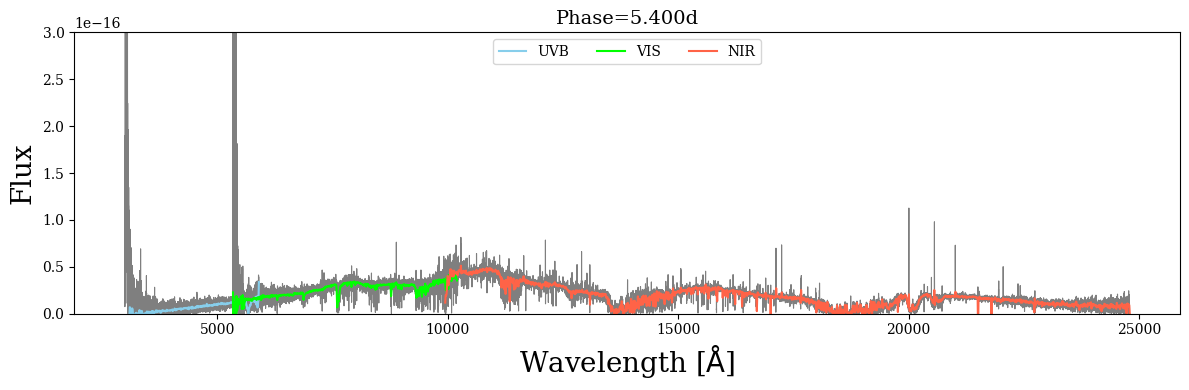

> Start processing for a phase=6.4d
Read tables
Merge tables and Save
Plot


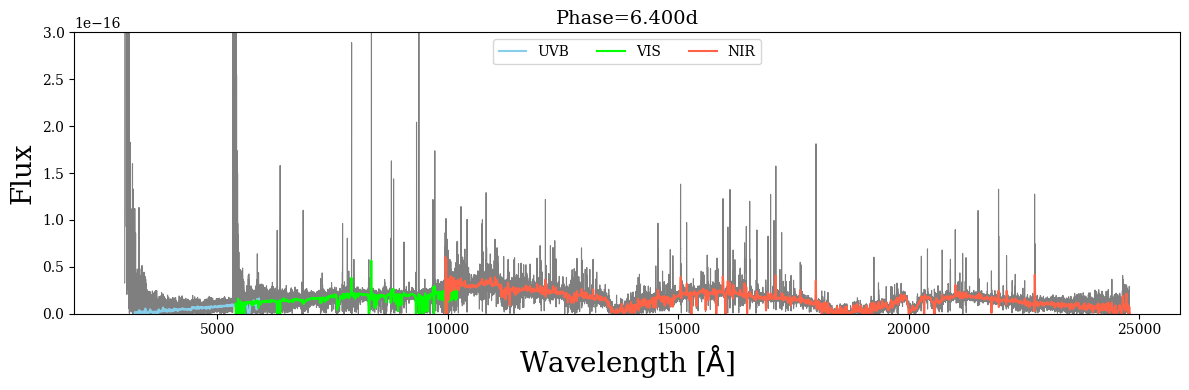

> Start processing for a phase=7.4d
Read tables
Merge tables and Save
Plot


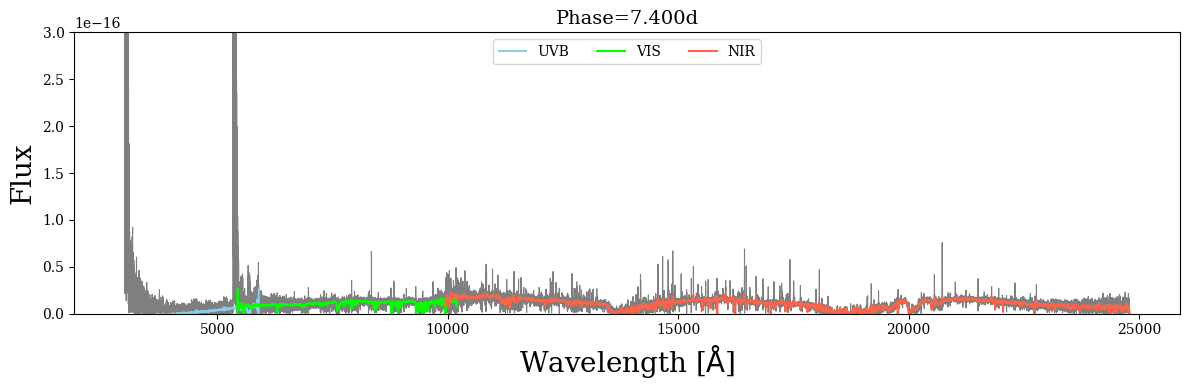

Done


In [77]:
path_save = f"{SPECTRA_DATA}/Engrave"
os.makedirs(path_save, exist_ok=True)

for phase in phases[:7]:
    print(f"> Start processing for a phase={phase}d")
    
    # Filename
    uvb_filename = glob.glob(f"{path_data}/UVB*{phase}*.dat")[0]
    vis_filename = glob.glob(f"{path_data}/VIS*{phase}*.dat")[0]
    nir_filename = glob.glob(f"{path_data}/NIR*{phase}*.dat")[0]

    # Output
    prefix = f"{path_save}/merged_flux_not_tell_corrected_phase{phase}d"
    plotname = f"{prefix}.png"
    specname = f"{prefix}.csv"
    
    # Table
    print(f"Read tables")
    uvbtbl = Table.read(uvb_filename, format='ascii.commented_header')
    vistbl = Table.read(vis_filename, format='ascii.commented_header')
    nirtbl = Table.read(nir_filename, format='ascii.commented_header')

    bin_uvbtbl = bin_spectrum(uvbtbl)
    bin_vistbl = bin_spectrum(vistbl)
    bin_nirtbl = bin_spectrum(nirtbl)

    # Merged Table
    print(f"Merge tables and Save")
    merged_tbl = merge_spectra_average_overlap(uvbtbl, vistbl, nirtbl)
    merged_tbl.write(specname)

    # Plot
    print(f"Plot")
    plt.figure(figsize=(12, 4))
    plt.plot(merged_tbl['wavelength'], merged_tbl['flux'], color='black', lw=0.8, alpha=0.5)
    plt.plot(bin_uvbtbl['wavelength'], bin_uvbtbl['flux'], color='skyblue', label='UVB')
    plt.plot(bin_vistbl['wavelength'], bin_vistbl['flux'], color='lime', label='VIS')
    plt.plot(bin_nirtbl['wavelength'], bin_nirtbl['flux'], color='tomato', label='NIR')
    plt.ylim(0, 3e-16)
    plt.xlabel(r"Wavelength [$\rm \AA$]")
    plt.ylabel("Flux")
    plt.title(f"Phase={phase:.3f}d")
    plt.tight_layout()
    plt.legend(loc='upper center', ncol=3)
    plt.savefig(plotname)
    plt.show()
    # break

print(f"Done")